# MA(2) synthetic vs fitted MA(q) vs TimesFM (expanding window)

**Setup.** Simulate $T=100$ observations from a Gaussian **MA(2)** process. For each forecast origin $k \in \{50,\ldots,99\}$ (0-based indices), use **only** past data $y_0,\ldots,y_{k-1}$ to predict the **next** value $y_k$ (the $(k+1)$-th observation in 1-based counting). That is **50** one-step-ahead predictions.

- **MA model:** Refit `ARIMA(0,0,q)` via MLE on $y[0:k]$ each time; one-step forecast.
- **TimesFM:** Load pretrained weights once; each step pass `inputs=[y[0:k]]` and `forecast(horizon=1)` — **no training**.

**Metrics.** Residuals $= y_k - \hat{y}_k$. Compare squared errors; `diff_sq = sq_err_tf - sq_err_ma` so **positive** values mean the **MA** forecast had **lower** squared error at that step.

## Dependencies

Install once in your environment (not declared in the root `pyproject.toml`):

```bash
uv pip install statsmodels pandas matplotlib ipywidgets python-dotenv
```

Optional: `load_dotenv()` so `HF_TOKEN` from a project `.env` is visible to Hugging Face Hub when downloading the model.

In [1]:
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

import torch
import timesfm

/Users/nikhileshbelulkar/Documents/timesfm/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Simulate MA(2)

$$y_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2}, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma^2).$$

We draw a long $\varepsilon$ sequence and slice so each $y_t$ uses consistent lags.

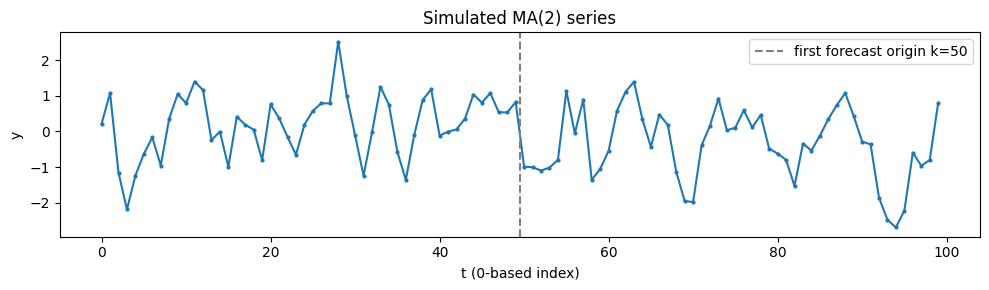

In [3]:
RNG_SEED = 42
T = 100
theta1, theta2 = 0.6, 0.3
sigma_eps = 1.0
q_ma = 2  # match DGP; change to explore misspecification

rng = np.random.default_rng(RNG_SEED)
e = rng.normal(0.0, sigma_eps, T + 2)
y = e[2 : T + 2] + theta1 * e[1 : T + 1] + theta2 * e[0:T]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.arange(T), y, marker=".", markersize=4)
ax.axvline(49.5, color="gray", linestyle="--", label="first forecast origin k=50")
ax.set_xlabel("t (0-based index)")
ax.set_ylabel("y")
ax.set_title("Simulated MA(2) series")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Load TimesFM (inference only)

- **`infer_is_positive=False`:** MA(2) paths can be negative; positivity constraints would be wrong here.
- **`max_horizon`:** Must be $\geq 1$; we only read the first step when `horizon=1`.
- **`from_pretrained`** may need network access and optionally `HF_TOKEN` for rate limits.

In [4]:
torch.set_float32_matmul_precision("high")

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=256,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=False,
        fix_quantile_crossing=True,
    )
)

## 3. Expanding-window one-step-ahead loop

For each $k \in \{50,\ldots,99\}$: train / condition on $y[0:k]$, predict $y[k]$.

In [7]:
k_start = 50
k_end = T  # exclusive upper bound for k in range(k_start, k_end) -> k = 50..99

rows = []
ma_failures = 0

for k in range(k_start, k_end):
    actual = float(y[k])
    history = y[:k].astype(np.float64)

    try:
        fit_ma = ARIMA(history, order=(0, 0, q_ma)).fit()
        pred_ma = float(np.asarray(fit_ma.forecast(steps=1)).ravel()[0])
    except Exception:
        pred_ma = np.nan
        ma_failures += 1

    point_forecast, _ = model.forecast(
        horizon=1,
        inputs=[history.astype(np.float32)],
    )

    pred_tf = float(point_forecast[0, 0])

    err_ma = actual - pred_ma
    err_tf = actual - pred_tf
    rows.append(
        {
            "k": k,
            "actual": actual,
            "pred_ma": pred_ma,
            "pred_tf": pred_tf,
            "err_ma": err_ma,
            "err_tf": err_tf,
            "sq_err_ma": err_ma**2 if np.isfinite(pred_ma) else np.nan,
            "sq_err_tf": err_tf**2,
        }
    )

results = pd.DataFrame(rows)
results["diff_sq"] = results["sq_err_tf"] - results["sq_err_ma"]
results["ma_wins_sq"] = results["sq_err_ma"] < results["sq_err_tf"]

print(f"MA fit failures: {ma_failures}")
results.head()

MA fit failures: 0


,k,actual,pred_ma,pred_tf,err_ma,err_tf,sq_err_ma,sq_err_tf,diff_sq,ma_wins_sq
0,50,-0.991647,0.654240,0.662989,-1.645887,-1.654636,2.708943,2.737819,0.028877,True
1,51,-1.004578,-0.714119,-0.331136,-0.290459,-0.673443,0.084366,0.453525,0.369159,True
2,52,-1.099322,-0.641417,-0.371363,-0.457905,-0.727959,0.209677,0.529925,0.320248,True
3,53,-1.017003,-0.224303,-0.457595,-0.792699,-0.559408,0.628372,0.312937,-0.315435,False
4,54,-0.799581,-0.576699,-0.659222,-0.222882,-0.140359,0.049676,0.019701,-0.029976,False


## 4. Summary metrics

Mean squared error (MAE) over the 50 steps; fraction of steps where MA(2) beats TimesFM on squared error.

In [8]:
mse_ma = results["sq_err_ma"].mean(skipna=True)
mse_tf = results["sq_err_tf"].mean()
mae_ma = results["err_ma"].abs().mean(skipna=True)
mae_tf = results["err_tf"].abs().mean()
frac_ma_wins = results["ma_wins_sq"].mean()

summary = pd.DataFrame(
    {
        "MSE": [mse_ma, mse_tf],
        "MAE": [mae_ma, mae_tf],
    },
    index=["MA", "TimesFM"],
)
print(summary)
print(f"\nFraction of steps where MA has lower squared error than TimesFM: {frac_ma_wins:.2%}")

              MSE       MAE
MA       0.670124  0.688759
TimesFM  0.773306  0.728825

Fraction of steps where MA has lower squared error than TimesFM: 58.00%


## 5. Plots

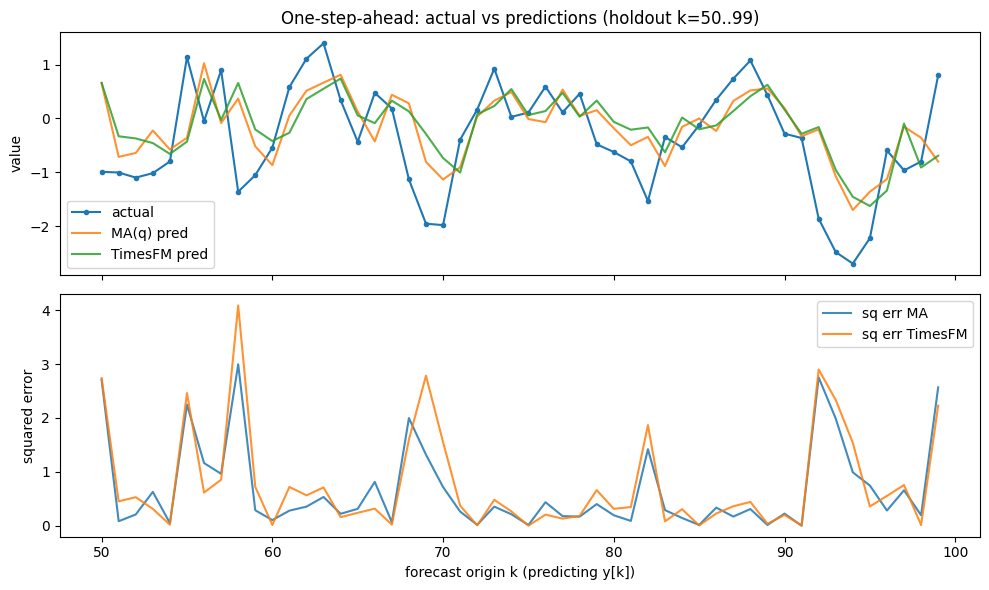

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

kx = results["k"].values
axes[0].plot(kx, results["actual"], label="actual", marker="o", markersize=3)
axes[0].plot(kx, results["pred_ma"], label="MA(q) pred", alpha=0.85)
axes[0].plot(kx, results["pred_tf"], label="TimesFM pred", alpha=0.85)
axes[0].set_ylabel("value")
axes[0].set_title("One-step-ahead: actual vs predictions (holdout k=50..99)")
axes[0].legend()

axes[1].plot(kx, results["sq_err_ma"], label="sq err MA", alpha=0.85)
axes[1].plot(kx, results["sq_err_tf"], label="sq err TimesFM", alpha=0.85)
axes[1].set_xlabel("forecast origin k (predicting y[k])")
axes[1].set_ylabel("squared error")
axes[1].legend()

plt.tight_layout()
plt.show()

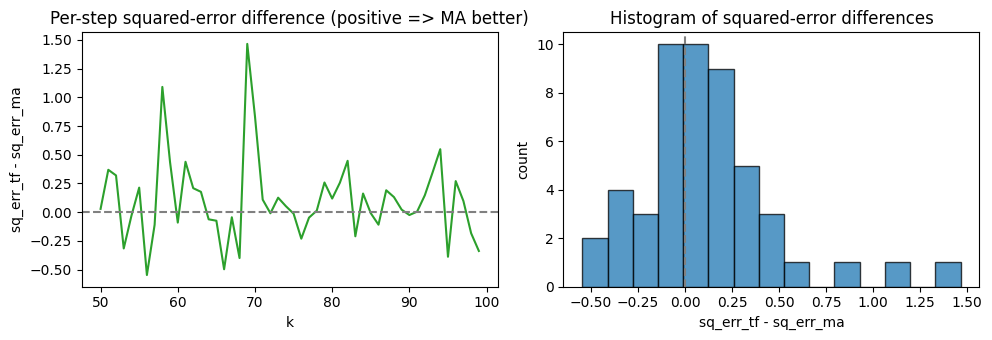

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(kx, results["diff_sq"], color="C2")
axes[0].axhline(0, color="gray", linestyle="--")
axes[0].set_xlabel("k")
axes[0].set_ylabel("sq_err_tf - sq_err_ma")
axes[0].set_title("Per-step squared-error difference (positive => MA better)")

axes[1].hist(results["diff_sq"].dropna(), bins=15, edgecolor="black", alpha=0.75)
axes[1].axvline(0, color="gray", linestyle="--")
axes[1].set_xlabel("sq_err_tf - sq_err_ma")
axes[1].set_ylabel("count")
axes[1].set_title("Histogram of squared-error differences")

plt.tight_layout()
plt.show()